In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
ev_data = pd.read_csv('/Users/anpabelt/Data Analytics/Dataset/Electric_Vehicle_Population_Size_History_By_County_.csv')
ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles
0,September 30 2022,Riverside,CA,Passenger,7,0,7,460,467,1.50
1,December 31 2022,Prince William,VA,Passenger,1,2,3,188,191,1.57
2,January 31 2020,Dakota,MN,Passenger,0,1,1,32,33,3.03
3,June 30 2022,Ferry,WA,Truck,0,0,0,"3,575","3,575",0.00
4,July 31 2021,Douglas,CO,Passenger,0,1,1,83,84,1.19
...,...,...,...,...,...,...,...,...,...,...
20814,January 31 2023,Rockingham,NH,Passenger,1,0,1,14,15,6.67
20815,July 31 2020,Carson City,NV,Passenger,1,0,1,10,11,9.09
20816,February 28 2022,Island,WA,Passenger,744,350,"1,094","62,257","63,351",1.73
20817,December 31 2020,San Diego,CA,Passenger,14,2,16,"2,724","2,740",0.58


In [ ]:
ev_data = pd.read_csv('/Users/anpabelt/Data Analytics/Dataset/Electric_Vehicle_Population_Size_History_By_County_.csv', parse_dates=['Date'])
ev_data.head()

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles
0,2022-09-30,Riverside,CA,Passenger,7,0,7,460,467,1.50
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03
3,2022-06-30,Ferry,WA,Truck,0,0,0,"3,575","3,575",0.00
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19


In [167]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20819 entries, 0 to 20818
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      20819 non-null  datetime64[ns]
 1   County                                    20733 non-null  object        
 2   State                                     20733 non-null  object        
 3   Vehicle Primary Use                       20819 non-null  object        
 4   Battery Electric Vehicles (BEVs)          20819 non-null  object        
 5   Plug-In Hybrid Electric Vehicles (PHEVs)  20819 non-null  object        
 6   Electric Vehicle (EV) Total               20819 non-null  object        
 7   Non-Electric Vehicle Total                20819 non-null  object        
 8   Total Vehicles                            20819 non-null  object        
 9   Percent Electric Vehicles   

In [168]:
ev_data['day'] = ev_data['Date'].dt.day
ev_data['month'] = ev_data['Date'].dt.month
ev_data['year'] = ev_data['Date'].dt.year
ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year
0,2022-09-30,Riverside,CA,Passenger,7,0,7,460,467,1.50,30,9,2022
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57,31,12,2022
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03,31,1,2020
3,2022-06-30,Ferry,WA,Truck,0,0,0,"3,575","3,575",0.00,30,6,2022
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19,31,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,2023-01-31,Rockingham,NH,Passenger,1,0,1,14,15,6.67,31,1,2023
20815,2020-07-31,Carson City,NV,Passenger,1,0,1,10,11,9.09,31,7,2020
20816,2022-02-28,Island,WA,Passenger,744,350,"1,094","62,257","63,351",1.73,28,2,2022
20817,2020-12-31,San Diego,CA,Passenger,14,2,16,"2,724","2,740",0.58,31,12,2020


In [169]:
ev_data["Battery Electric Vehicles (BEVs)"] = ev_data["Battery Electric Vehicles (BEVs)"].str.replace(",", "").str.replace(".","")
ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"] = ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"].str.replace(",", "").str.replace(".","")
ev_data["Electric Vehicle (EV) Total"] = ev_data["Electric Vehicle (EV) Total"].str.replace(",", "").str.replace(".","")
ev_data["Non-Electric Vehicle Total"] = ev_data["Non-Electric Vehicle Total"].str.replace(",", "").str.replace(".","")
ev_data["Total Vehicles"] = ev_data["Total Vehicles"].str.replace(",", "").str.replace(".","")

ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year
0,2022-09-30,Riverside,CA,Passenger,7,0,7,460,467,1.50,30,9,2022
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57,31,12,2022
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03,31,1,2020
3,2022-06-30,Ferry,WA,Truck,0,0,0,3575,3575,0.00,30,6,2022
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19,31,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,2023-01-31,Rockingham,NH,Passenger,1,0,1,14,15,6.67,31,1,2023
20815,2020-07-31,Carson City,NV,Passenger,1,0,1,10,11,9.09,31,7,2020
20816,2022-02-28,Island,WA,Passenger,744,350,1094,62257,63351,1.73,28,2,2022
20817,2020-12-31,San Diego,CA,Passenger,14,2,16,2724,2740,0.58,31,12,2020


In [170]:
ev_data["Battery Electric Vehicles (BEVs)"] = pd.to_numeric(ev_data["Battery Electric Vehicles (BEVs)"])
ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"] = pd.to_numeric(ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"])
ev_data["Electric Vehicle (EV) Total"] = pd.to_numeric(ev_data["Electric Vehicle (EV) Total"])
ev_data["Non-Electric Vehicle Total"] = pd.to_numeric(ev_data["Non-Electric Vehicle Total"])
ev_data["Total Vehicles"] = pd.to_numeric(ev_data["Total Vehicles"])

ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year
0,2022-09-30,Riverside,CA,Passenger,7,0,7,460,467,1.50,30,9,2022
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57,31,12,2022
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03,31,1,2020
3,2022-06-30,Ferry,WA,Truck,0,0,0,3575,3575,0.00,30,6,2022
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19,31,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,2023-01-31,Rockingham,NH,Passenger,1,0,1,14,15,6.67,31,1,2023
20815,2020-07-31,Carson City,NV,Passenger,1,0,1,10,11,9.09,31,7,2020
20816,2022-02-28,Island,WA,Passenger,744,350,1094,62257,63351,1.73,28,2,2022
20817,2020-12-31,San Diego,CA,Passenger,14,2,16,2724,2740,0.58,31,12,2020


In [171]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20819 entries, 0 to 20818
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      20819 non-null  datetime64[ns]
 1   County                                    20733 non-null  object        
 2   State                                     20733 non-null  object        
 3   Vehicle Primary Use                       20819 non-null  object        
 4   Battery Electric Vehicles (BEVs)          20819 non-null  int64         
 5   Plug-In Hybrid Electric Vehicles (PHEVs)  20819 non-null  int64         
 6   Electric Vehicle (EV) Total               20819 non-null  int64         
 7   Non-Electric Vehicle Total                20819 non-null  int64         
 8   Total Vehicles                            20819 non-null  int64         
 9   Percent Electric Vehicles   

In [172]:
ev_data['County'] = ev_data['County'].fillna('Unknown')
ev_data['State'] = ev_data['State'].fillna('Unknown')

In [173]:
ev_data.isnull().sum()

Date                                        0
County                                      0
State                                       0
Vehicle Primary Use                         0
Battery Electric Vehicles (BEVs)            0
Plug-In Hybrid Electric Vehicles (PHEVs)    0
Electric Vehicle (EV) Total                 0
Non-Electric Vehicle Total                  0
Total Vehicles                              0
Percent Electric Vehicles                   0
day                                         0
month                                       0
year                                        0
dtype: int64

In [174]:
ev_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,20819,2020-11-13 19:57:00.855949056,2017-01-31 00:00:00,2019-03-31 00:00:00,2020-12-31 00:00:00,2022-07-31 00:00:00,2024-02-29 00:00:00,NaN
Battery Electric Vehicles (BEVs),20819.0,217.516211,0.0,0.0,1.0,3.0,72333.0,2278.533317
Plug-In Hybrid Electric Vehicles (PHEVs),20819.0,80.063644,0.0,0.0,1.0,2.0,17501.0,646.373208
Electric Vehicle (EV) Total,20819.0,297.579855,0.0,1.0,1.0,4.0,89834.0,2915.504792
Non-Electric Vehicle Total,20819.0,25098.062539,0.0,43.0,163.0,8380.0,1399823.0,106732.436167
Total Vehicles,20819.0,25395.642394,1.0,44.0,165.0,8421.5,1430937.0,109085.96215
Percent Electric Vehicles,20819.0,4.139216,0.0,0.39,1.22,2.995,100.0,11.05535
day,20819.0,30.420433,28.0,30.0,31.0,31.0,31.0,0.838047
month,20819.0,6.416975,1.0,3.0,6.0,9.0,12.0,3.500581
year,20819.0,2020.339161,2017.0,2019.0,2020.0,2022.0,2024.0,2.014528


In [175]:
ev_data[ev_data.duplicated(keep=False)]

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year


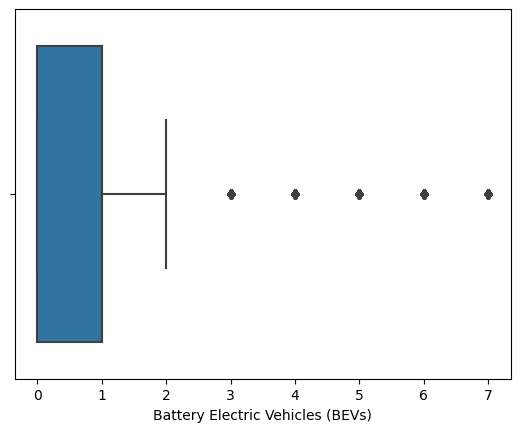

In [176]:
# Calculate IQR
Q1 = ev_data["Battery Electric Vehicles (BEVs)"].quantile(0.25)
Q3 = ev_data["Battery Electric Vehicles (BEVs)"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
BEV_max_limit = Q3 + 1.5 * IQR

# Calculate the median
BEV_median = ev_data["Battery Electric Vehicles (BEVs)"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Battery Electric Vehicles (BEVs)"] > BEV_max_limit, "Battery Electric Vehicles (BEVs)"] = BEV_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Battery Electric Vehicles (BEVs)"])
plt.show()


In [177]:
BEV_max_limit = ev_data["Battery Electric Vehicles (BEVs)"].quantile(q=0.75) * 1.5

BEV_median = ev_data["Battery Electric Vehicles (BEVs)"].median()

ev_data.loc[ev_data["Battery Electric Vehicles (BEVs)"] > BEV_max_limit, "Battery Electric Vehicles (BEVs)"]= BEV_median
ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year
0,2022-09-30,Riverside,CA,Passenger,1,0,7,460,467,1.50,30,9,2022
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57,31,12,2022
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03,31,1,2020
3,2022-06-30,Ferry,WA,Truck,0,0,0,3575,3575,0.00,30,6,2022
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19,31,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,2023-01-31,Rockingham,NH,Passenger,1,0,1,14,15,6.67,31,1,2023
20815,2020-07-31,Carson City,NV,Passenger,1,0,1,10,11,9.09,31,7,2020
20816,2022-02-28,Island,WA,Passenger,1,350,1094,62257,63351,1.73,28,2,2022
20817,2020-12-31,San Diego,CA,Passenger,1,2,16,2724,2740,0.58,31,12,2020


<Axes: xlabel='Plug-In Hybrid Electric Vehicles (PHEVs)'>

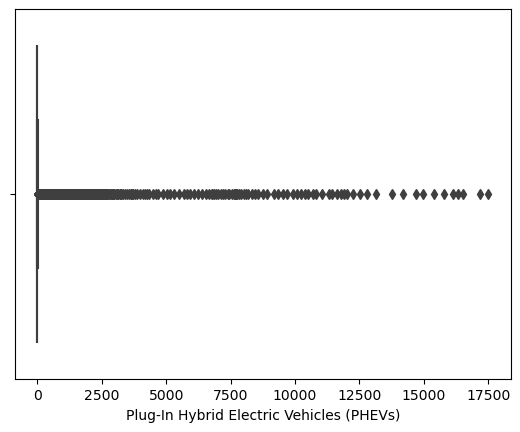

In [178]:
sns.boxplot(data=ev_data,x="Plug-In Hybrid Electric Vehicles (PHEVs)")

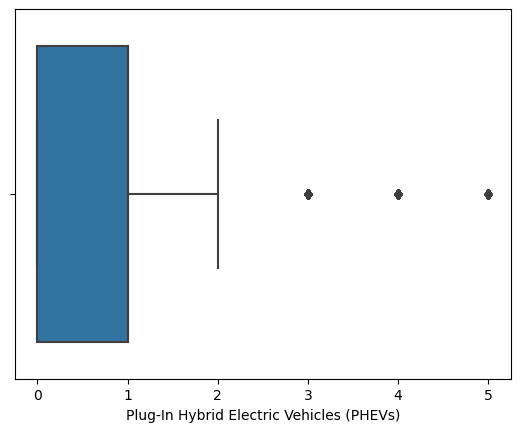

In [179]:
# Calculate IQR
Q1 = ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"].quantile(0.25)
Q3 = ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
plugin_max_limit = Q3 + 1.5 * IQR

# Calculate the median
plugin_median = ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"] > plugin_max_limit, "Plug-In Hybrid Electric Vehicles (PHEVs)"] = plugin_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Plug-In Hybrid Electric Vehicles (PHEVs)"])
plt.show()

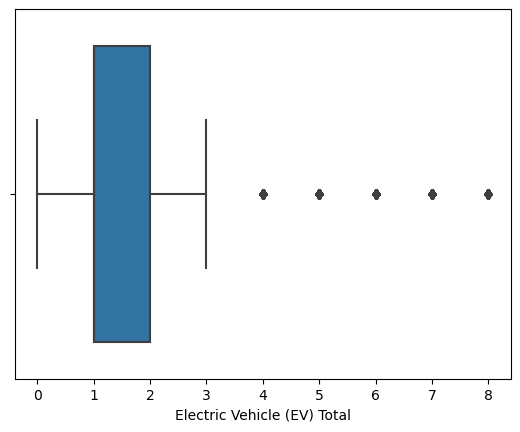

In [180]:
# Calculate IQR
Q1 = ev_data["Electric Vehicle (EV) Total"].quantile(0.25)
Q3 = ev_data["Electric Vehicle (EV) Total"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
elect_vehicle_max_limit = Q3 + 1.5 * IQR

# Calculate the median
elect_vehicle_median = ev_data["Electric Vehicle (EV) Total"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Electric Vehicle (EV) Total"] > elect_vehicle_max_limit, "Electric Vehicle (EV) Total"] = elect_vehicle_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Electric Vehicle (EV) Total"])
plt.show()

<Axes: xlabel='Non-Electric Vehicle Total'>

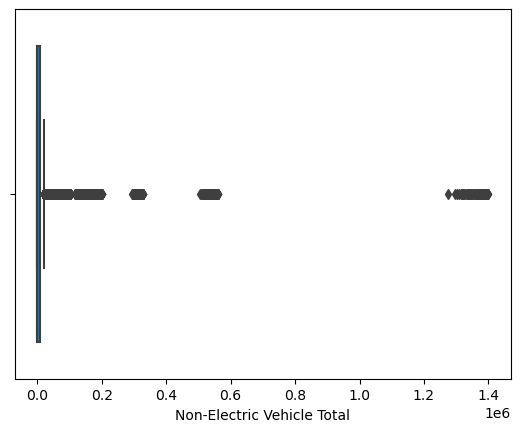

In [181]:
sns.boxplot(data=ev_data,x="Non-Electric Vehicle Total")

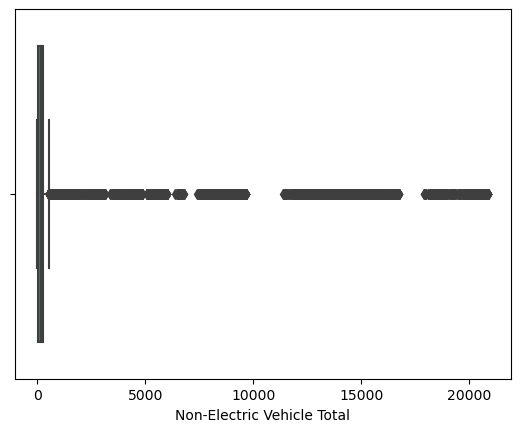

In [182]:
# Calculate IQR
Q1 = ev_data["Non-Electric Vehicle Total"].quantile(0.25)
Q3 = ev_data["Non-Electric Vehicle Total"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
non_ev_max_limit = Q3 + 1.5 * IQR

# Calculate the median
non_ev_median = ev_data["Non-Electric Vehicle Total"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Non-Electric Vehicle Total"] > non_ev_max_limit, "Non-Electric Vehicle Total"] = non_ev_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Non-Electric Vehicle Total"])
plt.show()

<Axes: xlabel='Total Vehicles'>

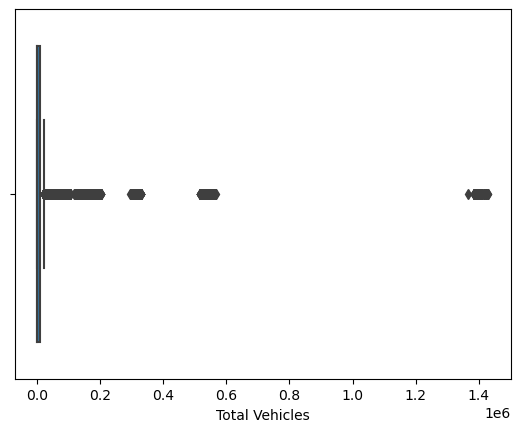

In [183]:
sns.boxplot(data=ev_data,x="Total Vehicles")

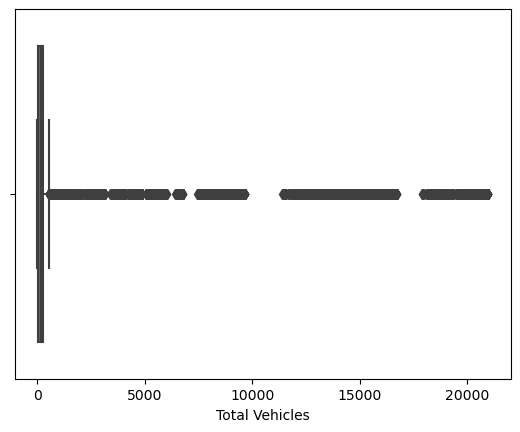

In [184]:
# Calculate IQR
Q1 = ev_data["Total Vehicles"].quantile(0.25)
Q3 = ev_data["Total Vehicles"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
vehicle_max_limit = Q3 + 1.5 * IQR

# Calculate the median
vehicle_median = ev_data["Total Vehicles"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Total Vehicles"] > vehicle_max_limit, "Total Vehicles"] = vehicle_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Total Vehicles"])
plt.show()

<Axes: xlabel='Percent Electric Vehicles'>

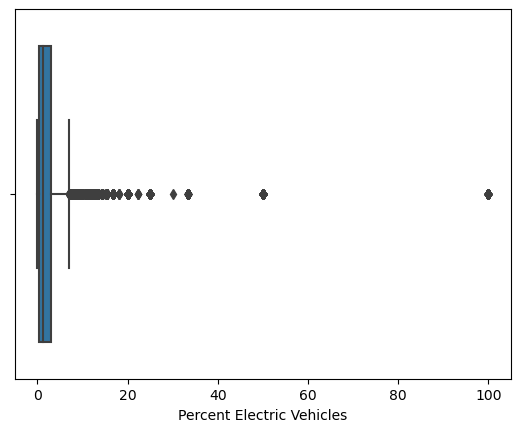

In [185]:
sns.boxplot(data=ev_data,x="Percent Electric Vehicles")

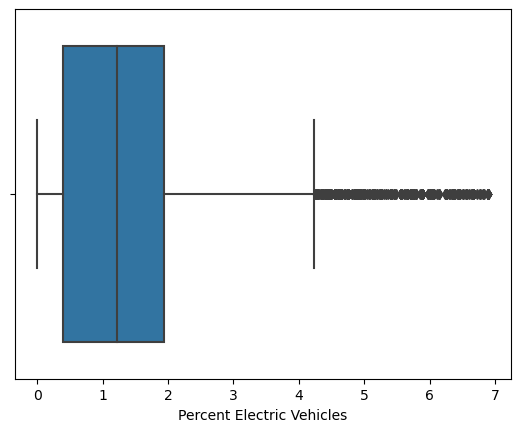

In [186]:
# Calculate IQR
Q1 = ev_data["Percent Electric Vehicles"].quantile(0.25)
Q3 = ev_data["Percent Electric Vehicles"].quantile(0.75)
IQR = Q3 - Q1

# Calculate the upper limit for outliers
percent_max_limit = Q3 + 1.5 * IQR

# Calculate the median
percent_median = ev_data["Percent Electric Vehicles"].median()

# Replace outliers with the median
ev_data.loc[ev_data["Percent Electric Vehicles"] > percent_max_limit, "Percent Electric Vehicles"] = percent_median

# Plot the boxplot again using the updated dataset
sns.boxplot(x=ev_data["Percent Electric Vehicles"])
plt.show()

In [187]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20819 entries, 0 to 20818
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      20819 non-null  datetime64[ns]
 1   County                                    20819 non-null  object        
 2   State                                     20819 non-null  object        
 3   Vehicle Primary Use                       20819 non-null  object        
 4   Battery Electric Vehicles (BEVs)          20819 non-null  int64         
 5   Plug-In Hybrid Electric Vehicles (PHEVs)  20819 non-null  int64         
 6   Electric Vehicle (EV) Total               20819 non-null  int64         
 7   Non-Electric Vehicle Total                20819 non-null  int64         
 8   Total Vehicles                            20819 non-null  int64         
 9   Percent Electric Vehicles   

In [188]:
ev_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,20819,2020-11-13 19:57:00.855949056,2017-01-31 00:00:00,2019-03-31 00:00:00,2020-12-31 00:00:00,2022-07-31 00:00:00,2024-02-29 00:00:00,NaN
Battery Electric Vehicles (BEVs),20819.0,0.674432,0.0,0.0,1.0,1.0,1.0,0.468598
Plug-In Hybrid Electric Vehicles (PHEVs),20819.0,0.707046,0.0,0.0,1.0,1.0,5.0,0.866546
Electric Vehicle (EV) Total,20819.0,1.487103,0.0,1.0,1.0,2.0,8.0,1.405069
Non-Electric Vehicle Total,20819.0,1389.769345,0.0,43.0,163.0,239.0,20885.0,3753.673434
Total Vehicles,20819.0,1425.088669,1.0,44.0,165.0,244.5,20985.0,3836.589478
Percent Electric Vehicles,20819.0,1.446559,0.0,0.39,1.22,1.93,6.9,1.452469
day,20819.0,30.420433,28.0,30.0,31.0,31.0,31.0,0.838047
month,20819.0,6.416975,1.0,3.0,6.0,9.0,12.0,3.500581
year,20819.0,2020.339161,2017.0,2019.0,2020.0,2022.0,2024.0,2.014528


In [189]:
ev_data

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles,day,month,year
0,2022-09-30,Riverside,CA,Passenger,1,0,7,460,467,1.50,30,9,2022
1,2022-12-31,Prince William,VA,Passenger,1,2,3,188,191,1.57,31,12,2022
2,2020-01-31,Dakota,MN,Passenger,0,1,1,32,33,3.03,31,1,2020
3,2022-06-30,Ferry,WA,Truck,0,0,0,3575,3575,0.00,30,6,2022
4,2021-07-31,Douglas,CO,Passenger,0,1,1,83,84,1.19,31,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,2023-01-31,Rockingham,NH,Passenger,1,0,1,14,15,6.67,31,1,2023
20815,2020-07-31,Carson City,NV,Passenger,1,0,1,10,11,1.22,31,7,2020
20816,2022-02-28,Island,WA,Passenger,1,1,1,163,165,1.73,28,2,2022
20817,2020-12-31,San Diego,CA,Passenger,1,2,1,2724,2740,0.58,31,12,2020


In [190]:
ev_groupby_county = ev_data.groupby(["County"]).agg({
    "Electric Vehicle (EV) Total": "sum", 
    "Total Vehicles": "sum",
    "Non-Electric Vehicle Total": "sum",
    "Plug-In Hybrid Electric Vehicles (PHEVs)": "sum",
    "Battery Electric Vehicles (BEVs)": "sum",
    "Percent Electric Vehicles": "mean"}).reset_index()

# Calculate Electric Vehicle Ratio within each county
ev_groupby_county["Electric Vehicle Ratio"] = ev_groupby_county["Electric Vehicle (EV) Total"] / ev_groupby_county["Total Vehicles"]

# Display the resulting DataFrame
(ev_groupby_county)

,County,Electric Vehicle (EV) Total,Total Vehicles,Non-Electric Vehicle Total,Plug-In Hybrid Electric Vehicles (PHEVs),Battery Electric Vehicles (BEVs),Percent Electric Vehicles,Electric Vehicle Ratio
0,Ada,98,15408,15310,58,27,0.808281,0.006360
1,Adams,208,1554217,1552459,160,131,0.577806,0.000134
2,Alameda,322,23748,23426,75,67,1.596163,0.013559
3,Albemarle,118,1846,1728,11,65,2.647895,0.063922
4,Alexandria,175,7434,7259,12,62,2.597742,0.023540
...,...,...,...,...,...,...,...,...
307,Yavapai,25,766,741,24,1,3.676000,0.032637
308,Yellowstone,24,430,406,24,0,3.972083,0.055814
309,Yolo,12,252,240,0,12,4.842500,0.047619
310,York,27,2159,2132,0,27,1.276667,0.012506


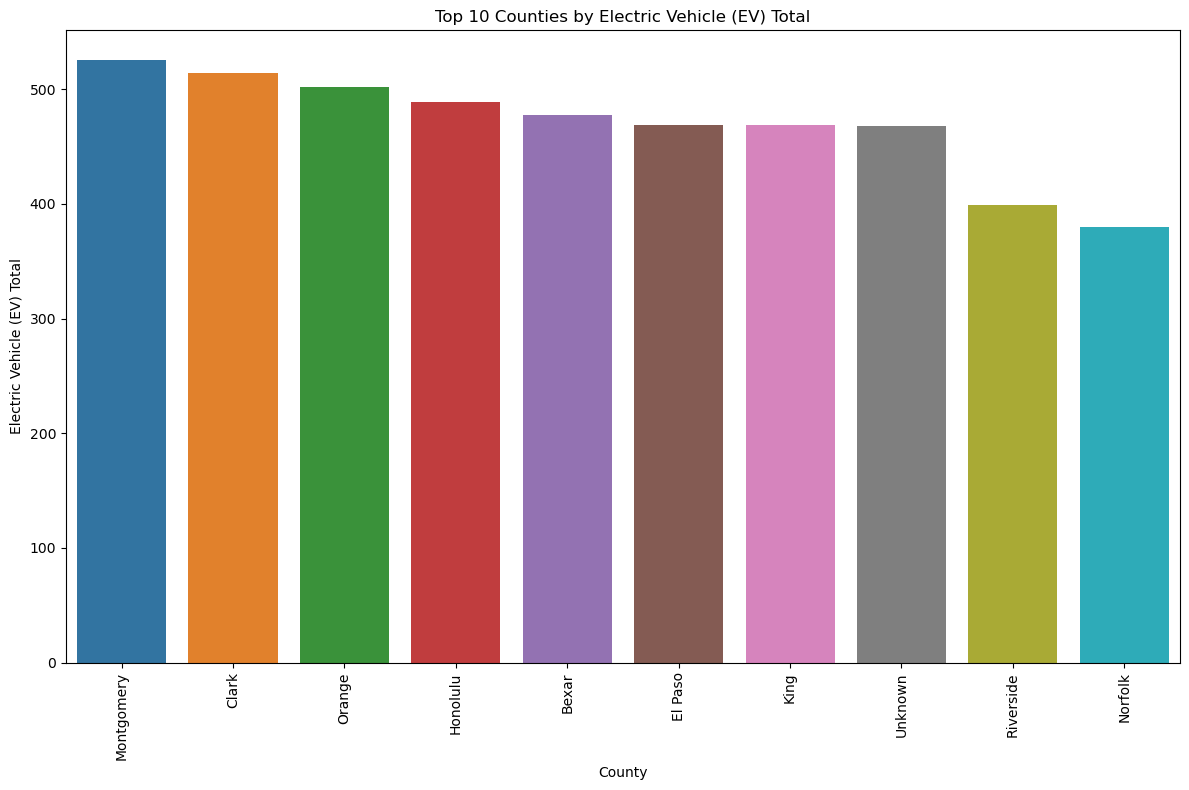

In [204]:
ev_groupby_county = ev_groupby_county.sort_values(by="Electric Vehicle (EV) Total", ascending=False)

plt.figure(figsize=(12, 8))
plt.title("Top 10 Counties by Electric Vehicle (EV) Total")
plt.xticks(rotation=90)

# Correct the sns.barplot usage
sns.barplot(data=ev_groupby_county.head(10), x="County", y="Electric Vehicle (EV) Total")

# To make the plot more readable, you might want to add this
plt.tight_layout()

plt.show()


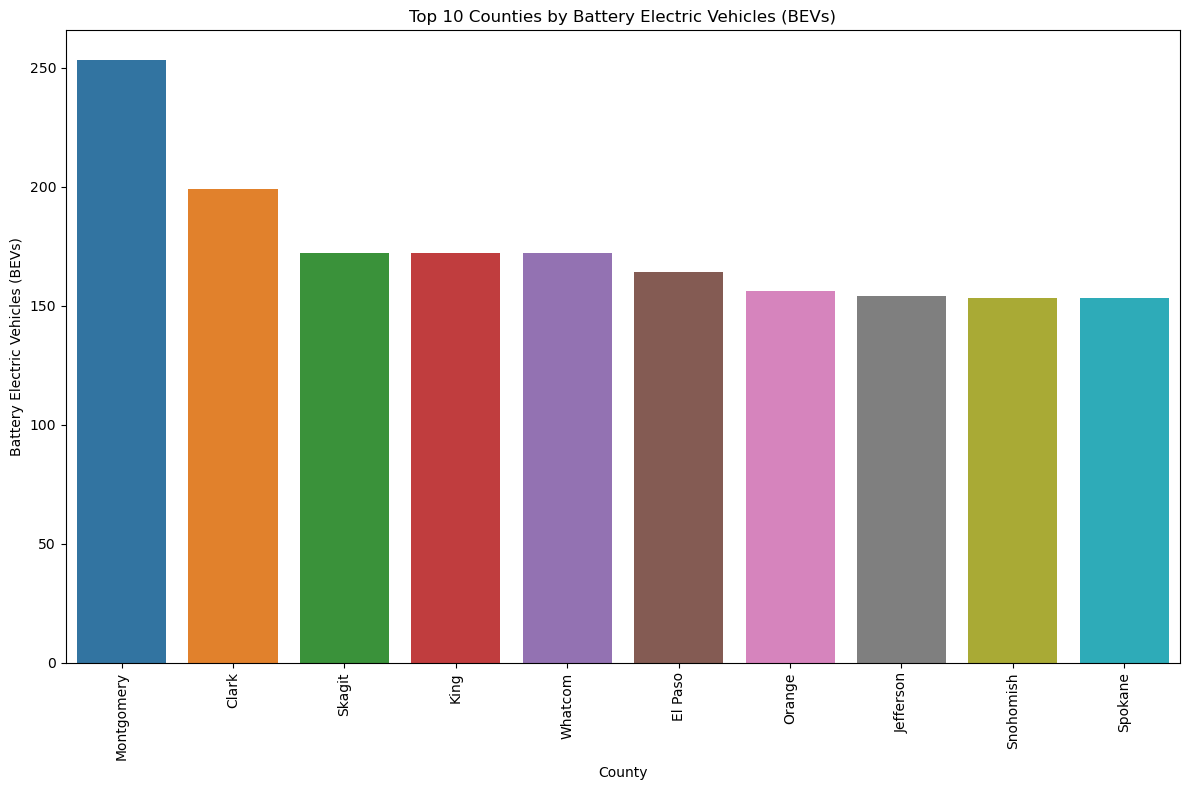

In [205]:
ev_groupby_county = ev_groupby_county.sort_values(by="Battery Electric Vehicles (BEVs)", ascending=False)

plt.figure(figsize=(12, 8))
plt.title("Top 10 Counties by Battery Electric Vehicles (BEVs)")
plt.xticks(rotation=90)

# Correct the sns.barplot usage
sns.barplot(data=ev_groupby_county.head(10), x="County", y="Battery Electric Vehicles (BEVs)")

# To make the plot more readable, you might want to add this
plt.tight_layout()

plt.show()

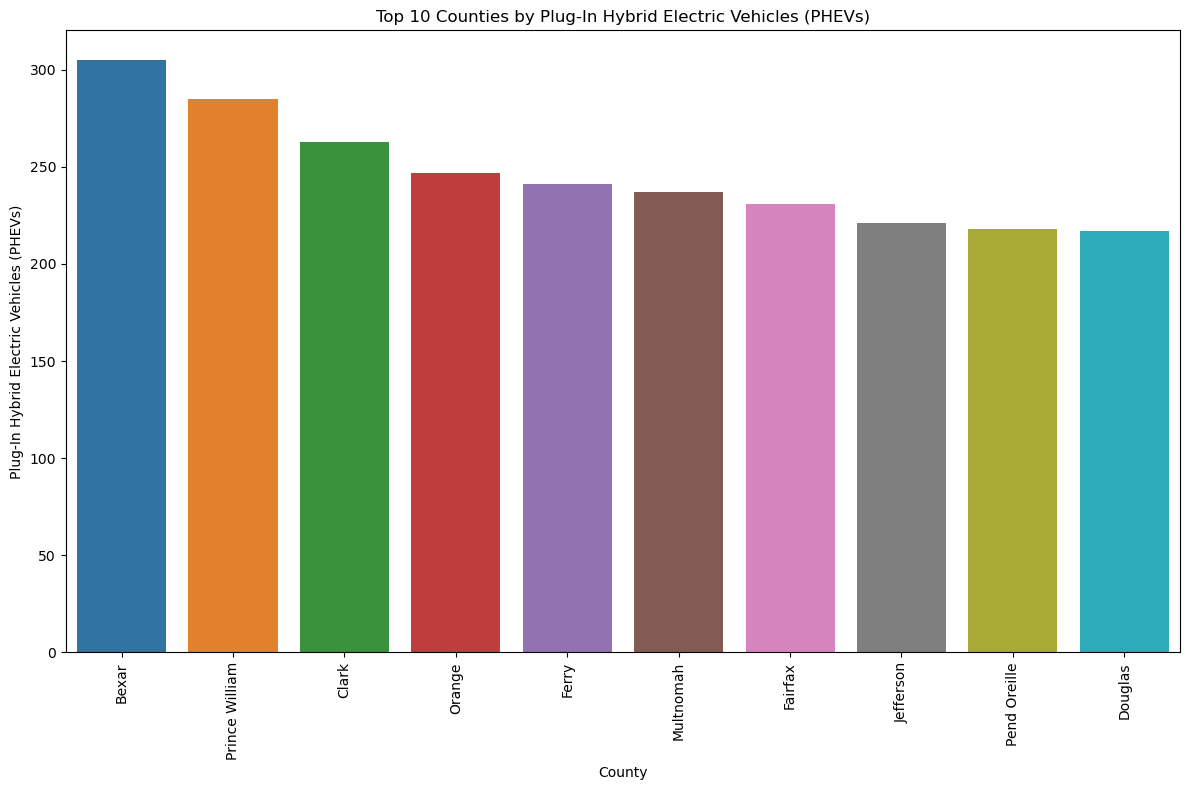

In [206]:
ev_groupby_county = ev_groupby_county.sort_values(by="Plug-In Hybrid Electric Vehicles (PHEVs)", ascending=False)

plt.figure(figsize=(12, 8))
plt.title("Top 10 Counties by Plug-In Hybrid Electric Vehicles (PHEVs)")
plt.xticks(rotation=90)

# Correct the sns.barplot usage
sns.barplot(data=ev_groupby_county.head(10), x="County", y="Plug-In Hybrid Electric Vehicles (PHEVs)")

# To make the plot more readable, you might want to add this
plt.tight_layout()

plt.show()

In [194]:
ev_groupby_year = ev_data.groupby("year").agg({"Electric Vehicle (EV) Total": "sum", "Total Vehicles": "sum"})

ev_groupby_year["year"]=ev_groupby_year.index

ev_groupby_year

,Electric Vehicle (EV) Total,Total Vehicles,year
year,,,
2017,2907,4377550,2017
2018,3359,4316735,2018
2019,3962,4253532,2019
2020,4156,4151444,2020
2021,4678,3789128,2021
2022,5449,3875962,2022
2023,5584,4177165,2023
2024,865,727405,2024


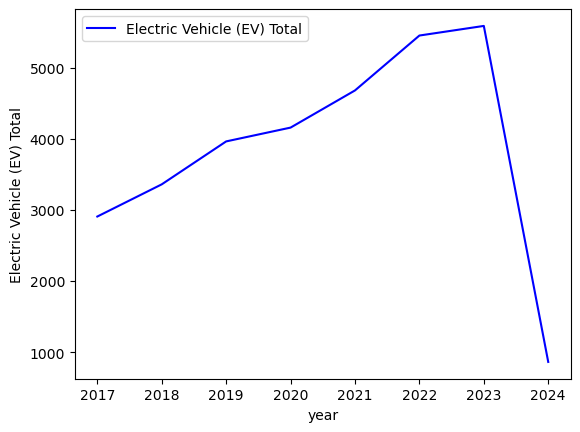

In [195]:
ev_groupby_year = ev_data.groupby('year').agg({ "Electric Vehicle (EV) Total": "sum",
        # Replace "Total Vehicles" with the correct column name for the sum of all vehicles if it exists 
}).reset_index()

plt.plot(ev_groupby_year['year'], ev_groupby_year['Electric Vehicle (EV) Total'], color='blue', label='Electric Vehicle (EV) Total')
plt.xlabel('year')
plt.ylabel('Electric Vehicle (EV) Total')
plt.legend()
plt.show()

In [196]:
ev_corr = ev_data[['Battery Electric Vehicles (BEVs)', 'Plug-In Hybrid Electric Vehicles (PHEVs)', 'Electric Vehicle (EV) Total', 'Non-Electric Vehicle Total', 'Total Vehicles', 'Percent Electric Vehicles']]
ev_corr.corr()

,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles
Battery Electric Vehicles (BEVs),1.000000,-0.082883,0.334620,-0.129831,-0.126920,0.131277
Plug-In Hybrid Electric Vehicles (PHEVs),-0.082883,1.000000,0.475748,-0.054479,-0.059053,0.043642
Electric Vehicle (EV) Total,0.334620,0.475748,1.000000,-0.122248,-0.114189,0.129088
Non-Electric Vehicle Total,-0.129831,-0.054479,-0.122248,1.000000,0.978635,-0.278519
Total Vehicles,-0.126920,-0.059053,-0.114189,0.978635,1.000000,-0.279472
Percent Electric Vehicles,0.131277,0.043642,0.129088,-0.278519,-0.279472,1.000000


<Axes: title={'center': 'EV Sales Correlation Heat Map'}>

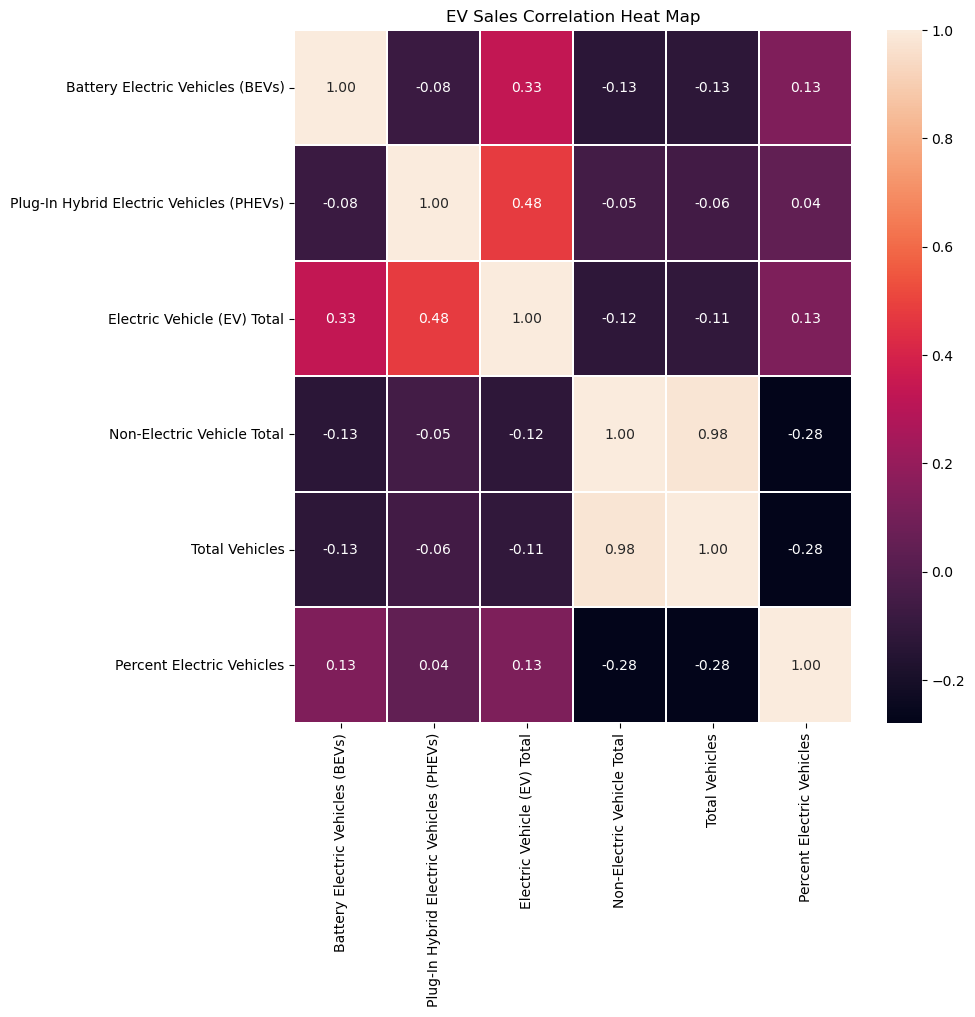

In [197]:
f, ax = plt.subplots(figsize=(9, 9))
ax.set_title('EV Sales Correlation Heat Map')
sns.heatmap(ev_corr.corr(), annot=True, robust=True, linewidths=.1, fmt= '.2f', ax = ax )

In [198]:
ev_data['Vehicle Primary Use'] = ev_data['Vehicle Primary Use'].map({'Passenger': 1,'Truck' : 0})

In [199]:
ev_total = ev_data['Electric Vehicle (EV) Total'].sum()
non_ev_total = ev_data['Non-Electric Vehicle Total'].sum()

            
print(f"Electric Vehicle (EV) Total: {ev_total}")
print(f"Non-Electric Vehicle Total: {non_ev_total}")

Electric Vehicle (EV) Total: 30960
Non-Electric Vehicle Total: 28933608


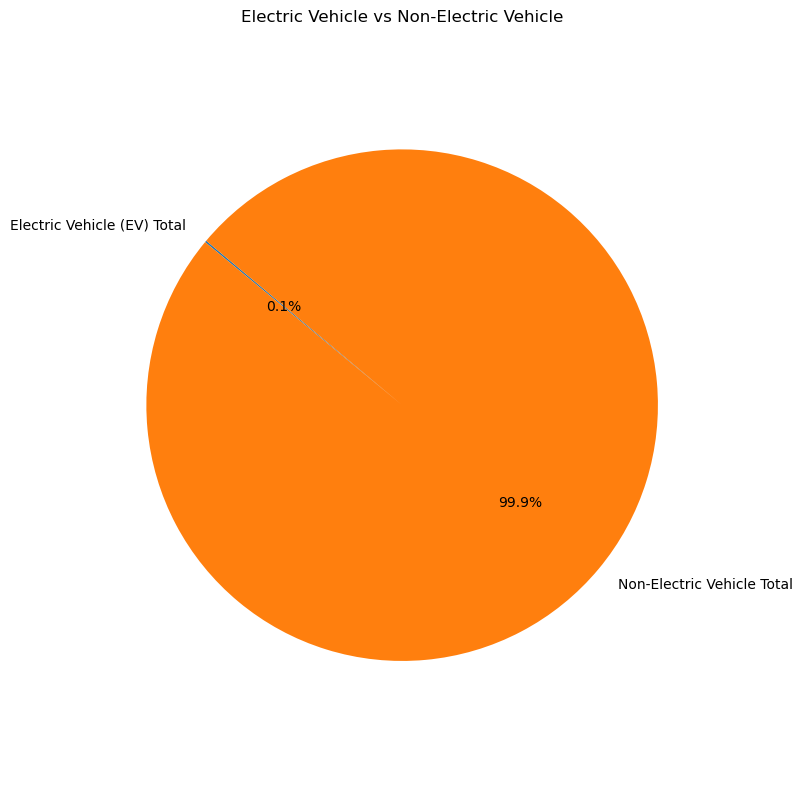

In [200]:
plt.figure(figsize=(8, 8))
labels = ['Electric Vehicle (EV) Total', 'Non-Electric Vehicle Total']
sizes = [ev_data['Electric Vehicle (EV) Total'].sum(), ev_data['Non-Electric Vehicle Total'].sum()]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Electric Vehicle vs Non-Electric Vehicle')
plt.axis('equal')
plt.tight_layout()
plt.show()



In [201]:
BEV_total = ev_data['Battery Electric Vehicles (BEVs)'].sum()
PLUGIN_total = ev_data['Plug-In Hybrid Electric Vehicles (PHEVs)'].sum()

            
print(f"Battery Electric Vehicles (BEVs) Total: {BEV_total}")
print(f"Plug-In Hybrid Electric Vehicles (PHEVs): {PLUGIN_total}")

Battery Electric Vehicles (BEVs) Total: 14041
Plug-In Hybrid Electric Vehicles (PHEVs): 14720


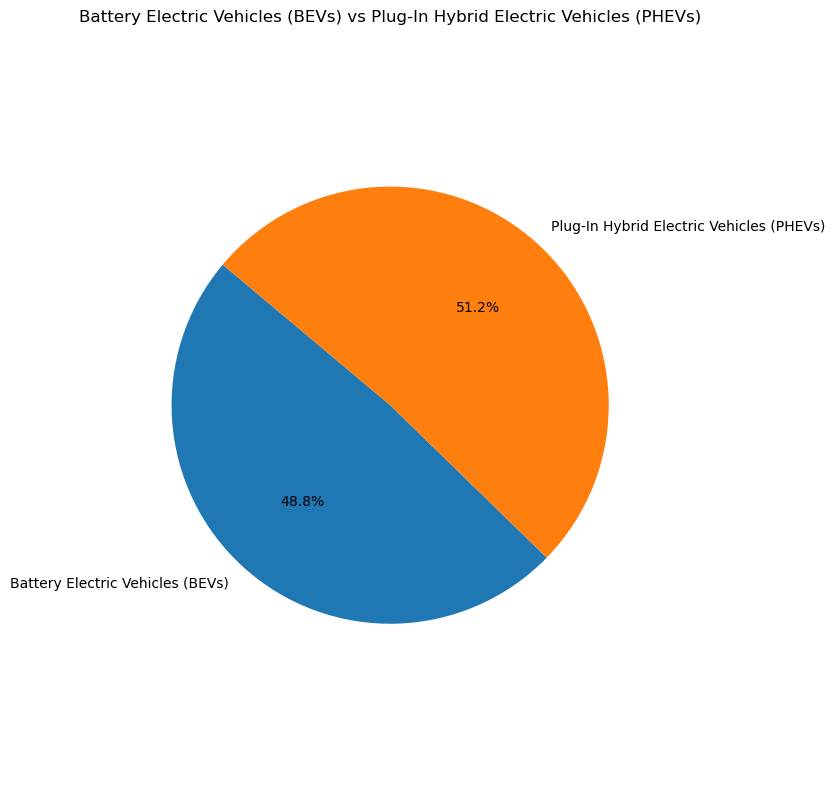

In [202]:
plt.figure(figsize=(8, 8))
labels = ['Battery Electric Vehicles (BEVs)', 'Plug-In Hybrid Electric Vehicles (PHEVs)']
sizes = [ev_data['Battery Electric Vehicles (BEVs)'].sum(), ev_data['Plug-In Hybrid Electric Vehicles (PHEVs)'].sum()]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Battery Electric Vehicles (BEVs) vs Plug-In Hybrid Electric Vehicles (PHEVs)')
plt.axis('equal')
plt.tight_layout()
plt.show()